# *Hospital Readmission Prediction* 

## Step 1 : Loading the  DataSet

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df=pd.read_csv(r"D:\DS\Projects\ML\Hospital_Readmissions\hospital_readmissions_RAW.csv")
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,0,0,Missing,Circulatory,Other,Circulatory,no,normal,no,no,yes
24996,[80-90),2,66,0,24,0,0,0,Missing,Digestive,Injury,Other,no,high,yes,yes,yes
24997,[70-80),5,12,0,6,0,1,0,Missing,Other,Other,Other,normal,no,no,no,yes
24998,[70-80),2,61,3,15,0,0,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,yes,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [5]:
df.size

425000

## Step 2 : Exploratory Data Analysis

- We perform Exploratory Data Analysis (EDA) to understand the data, visualize patterns, and identify relationships between features.
- If no meaningful relationships or associations are present, further analysis or model building may not be useful.

In [6]:
df.describe()


,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


## 2.1 During EDA, we must chect 
- NaN Values
- NUll Values
- Duplicates
- Eq=0
- Outliers
- Meaning less values 

In [7]:
df.isna().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

#### Fortunately the are no NaN Values, So Continue..........

In [8]:
df.duplicated().sum()

np.int64(0)

#### Also the are no Duplicate Values, So Continue..........

In [9]:
df.eq(0).sum()

age                      0
time_in_hospital         0
n_lab_procedures         0
n_procedures         11409
n_medications            0
n_outpatient         20859
n_inpatient          16537
n_emergency          22272
medical_specialty        0
diag_1                   0
diag_2                   0
diag_3                   0
glucose_test             0
A1Ctest                  0
change                   0
diabetes_med             0
readmitted               0
dtype: int64

#### Columns Like `n_procedures`  `n_outpatient` `n_inpatient` `n_emergency`  Contain Significant amount of 0's But they were Meaning full According to ML model

In [13]:
df.describe([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
10%,1.00000,13.00000,0.000000,7.900000,0.000000,0.000000,0.000000
20%,2.00000,27.00000,0.000000,10.000000,0.000000,0.000000,0.000000
30%,3.00000,35.00000,0.000000,12.000000,0.000000,0.000000,0.000000
40%,3.00000,40.00000,0.000000,13.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
60%,4.00000,49.00000,1.000000,17.000000,0.000000,0.000000,0.000000


### Here we were finding the Outliers through  IQR Method 
## Here We go Method for Numericals

In [14]:
def IQR(df, col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    LB= Q1-(IQR*1.5)
    UB= Q3+(IQR*1.5)
    return f'{col} feature consist  : {np.size(df[col][(df[col].values >UB) | (df[col].values <LB)])} Outliers'

In [15]:
Num_col=(df.select_dtypes(include='number')).columns
Num_col

Index(['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
       'n_outpatient', 'n_inpatient', 'n_emergency'],
      dtype='object')

In [16]:
for every in Num_col:
    print(IQR(df,every))

time_in_hospital feature consist  : 580 Outliers
n_lab_procedures feature consist  : 33 Outliers
n_procedures feature consist  : 1227 Outliers
n_medications feature consist  : 844 Outliers
n_outpatient feature consist  : 4141 Outliers
n_inpatient feature consist  : 1628 Outliers
n_emergency feature consist  : 2728 Outliers


### Visualizing the all the Outliers '


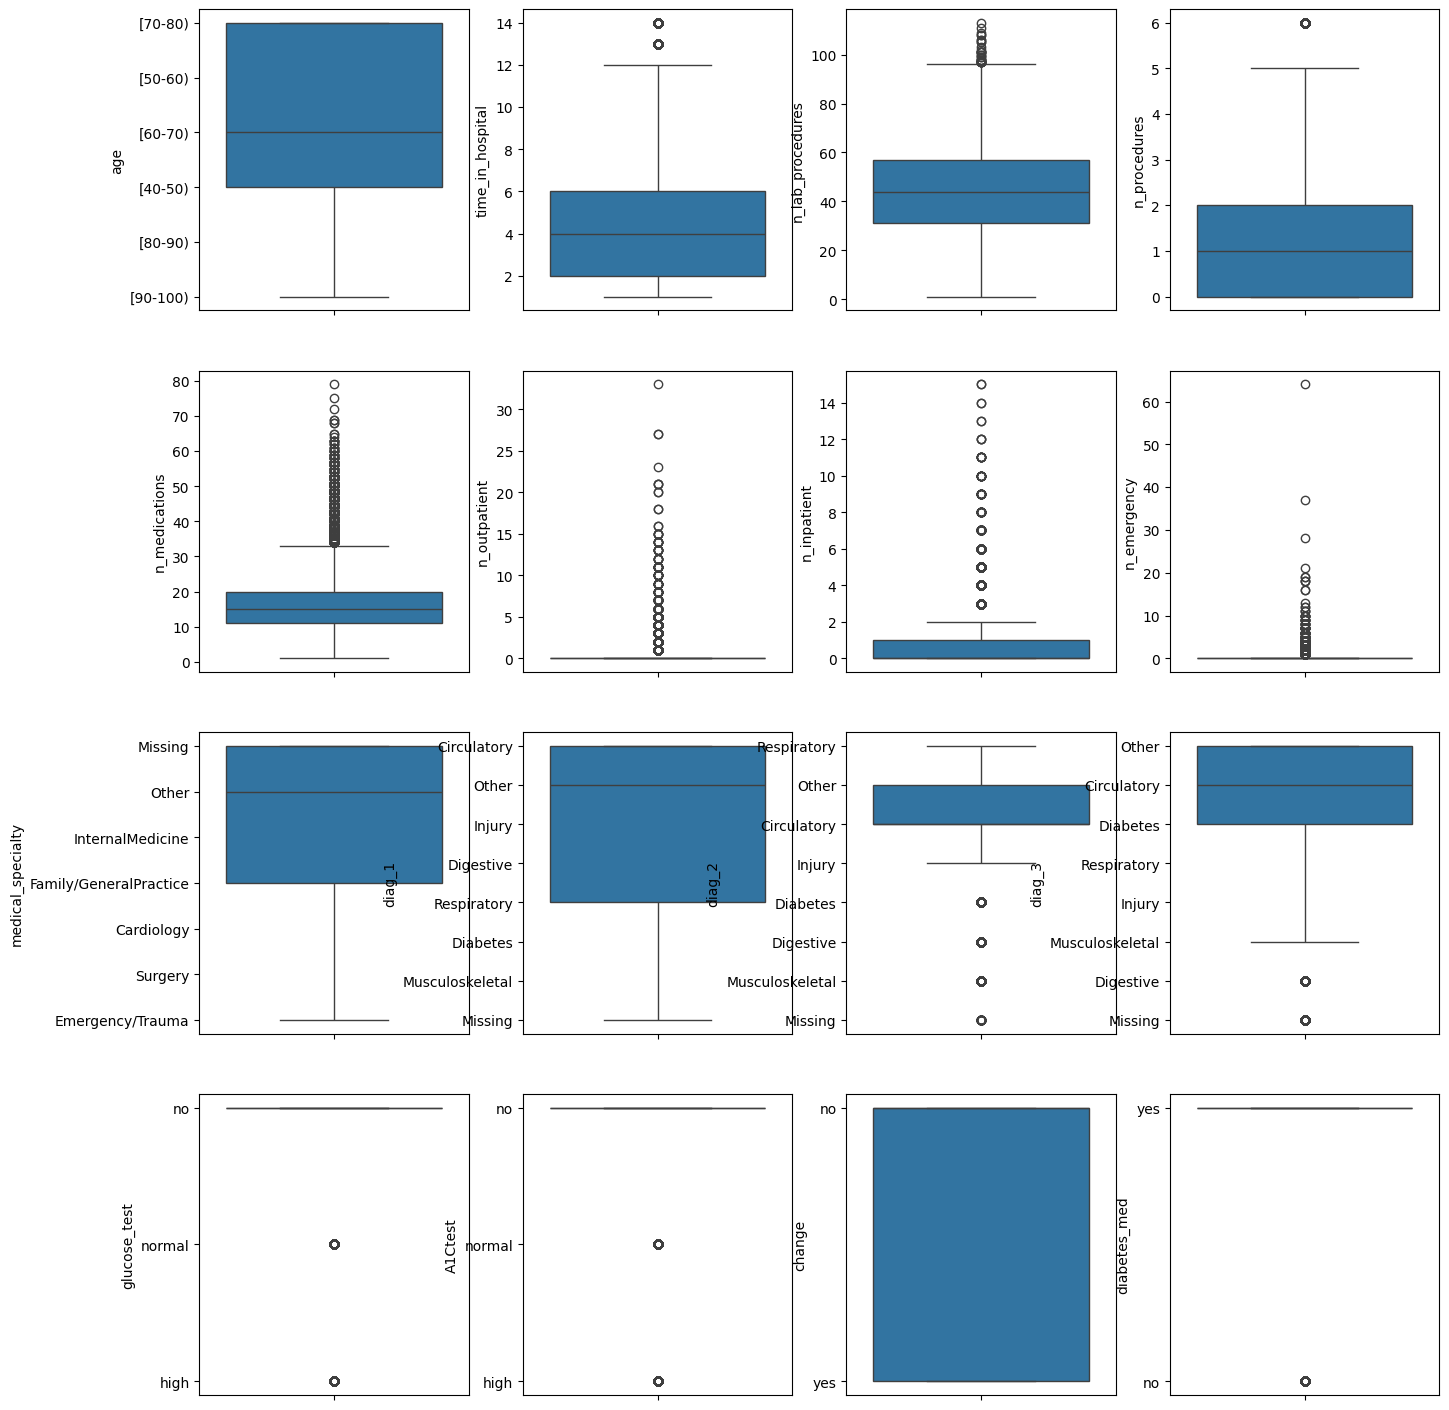

In [17]:
# Out of 17 Columns 16 were belongs to X and Only  1 Target so Iam takinhg 16 Subplots 
lst=df.columns
fig,aix=plt.subplots(4,4, figsize=(16,18))
aix=aix.flatten()
for i in range(16):
    sb.boxplot(df,y=lst[i], ax=aix[i])

## Although several extreme values appear as outliers in the boxplots, they are retained because medical measurements can vary significantly across individuals. These values may represent genuine patient conditions rather than data errors, so no outlier treatment is applied at this stage.

In [18]:
df.medical_specialty.value_counts()

medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

In [19]:
### 12k + Missing is meaning less so we should, rewritem them as 'Not specified' 

df['medical_specialty'] = df['medical_specialty'].replace('Missing', 'Not specified')


## 2.2 Finding the assoiations between Input (Fetures X) and Target y
- for Num vs Num    ---->  Scatterplot
- for Num vs Cat    ---->  BOX plot 
- for Cat vs Num    ---->  Box plot 
- for Num vs Num    ---->  Heatmap

In [20]:

target=df['readmitted']
Num_Cols=df.select_dtypes(include='number').columns
Num_Cols


Index(['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
       'n_outpatient', 'n_inpatient', 'n_emergency'],
      dtype='object')

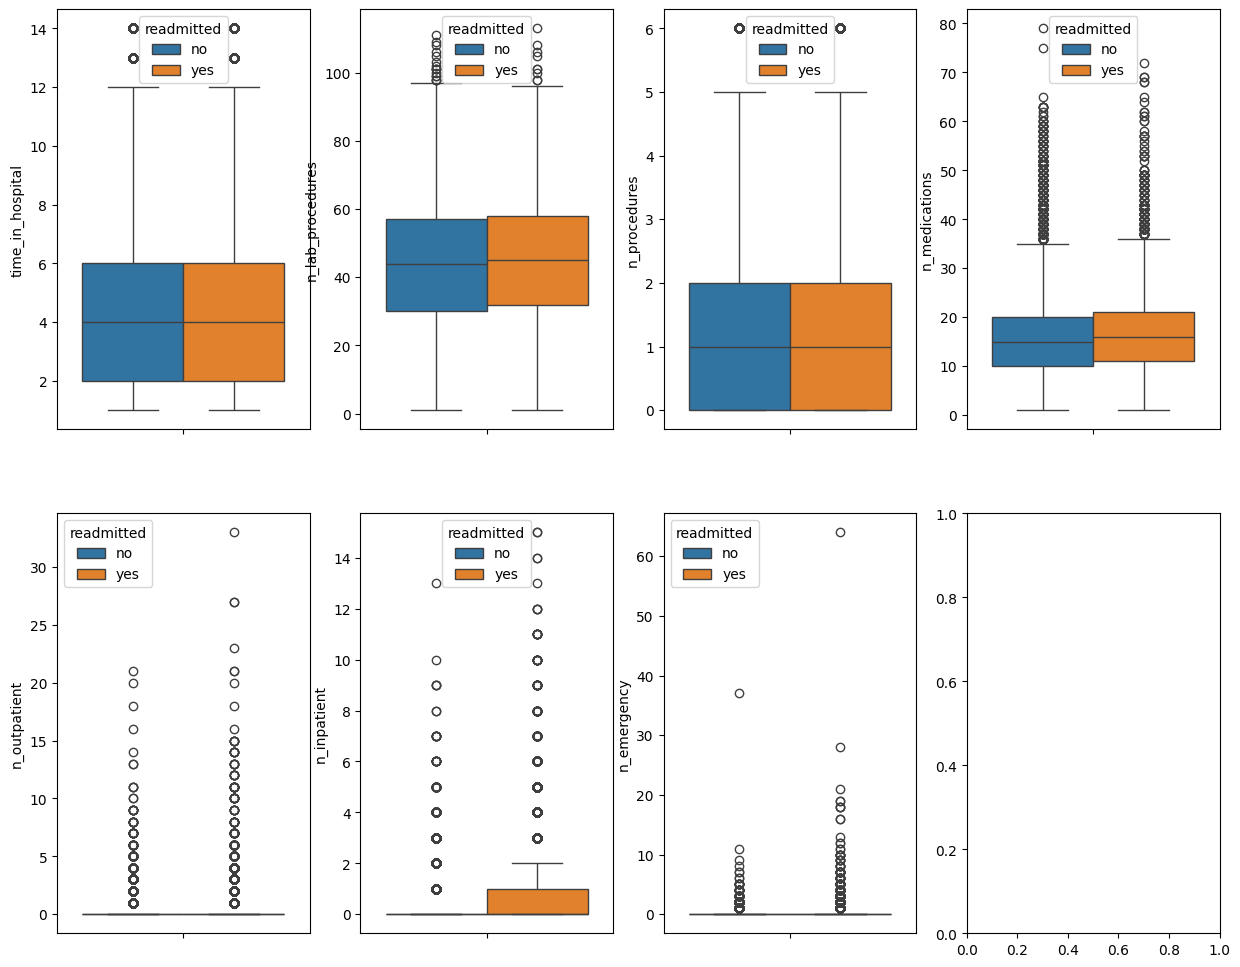

In [21]:
# Since  target is categorical   it is num vs cal so Box plots 
fig,ax=plt.subplots(2,4, figsize=(15,12))
ax=ax.flatten()
for i in range(len(Num_Cols)):
    sb.boxplot(df, y=Num_Cols[i], hue=target, ax=ax[i])
    
    

In [22]:
# Cat vs cat 
Cat_cols=df.select_dtypes(exclude='number').columns
Cat_cols

Index(['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

<Axes: xlabel='readmitted', ylabel='age'>

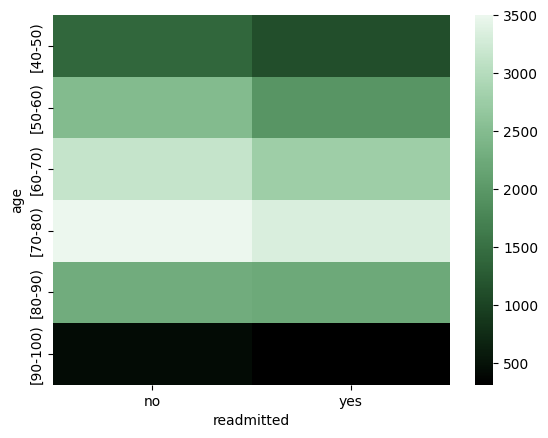

In [23]:
# age vs readmitted status
X=pd.crosstab(df.age, df.readmitted)
color=sb.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=True, as_cmap=True)
sb.heatmap(X, cmap=color)

## `Observation` ::  Age group between [70- 80] are repetedly readmitting into hosipatal

<Axes: xlabel='readmitted', ylabel='medical_specialty'>

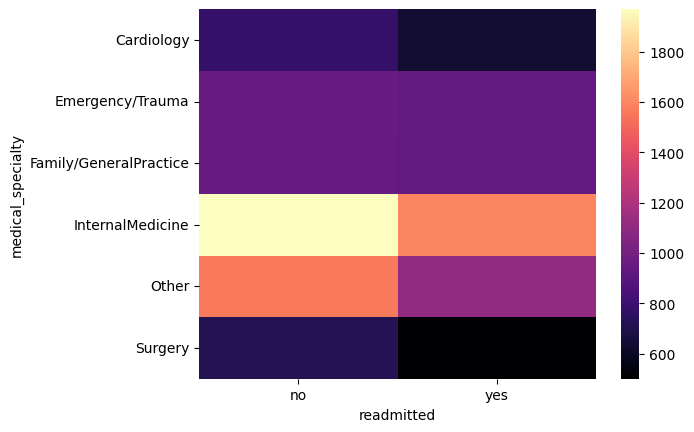

In [50]:
# age vs readmitted status
x_temp=df.medical_specialty[df.medical_specialty!='Not specified']
X=pd.crosstab(x_temp, df.readmitted)
color=sb.color_palette("magma", as_cmap=True)
sb.heatmap(X, cmap=color)

- Internal Medicine handles the most patients
-  Cardiology shows relatively higher readmission tendency

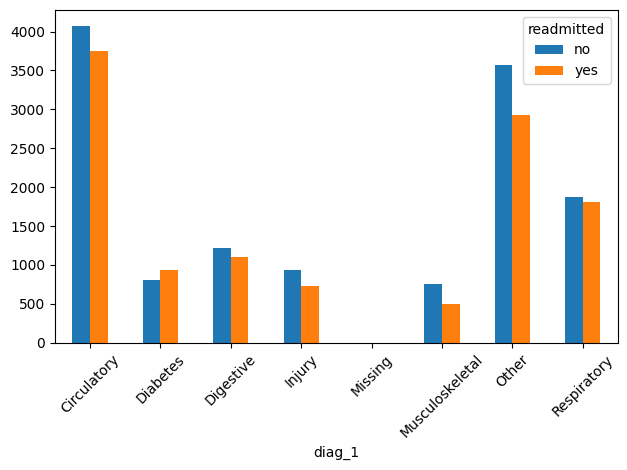

In [55]:
## Cat Vs Cat using stacked barchat 
top = df['diag_1'].value_counts().head(10).index
ct = pd.crosstab(df[df['diag_1'].isin(top)]['diag_1'],
                 df[df['diag_1'].isin(top)]['readmitted'])

ct.plot(kind='bar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

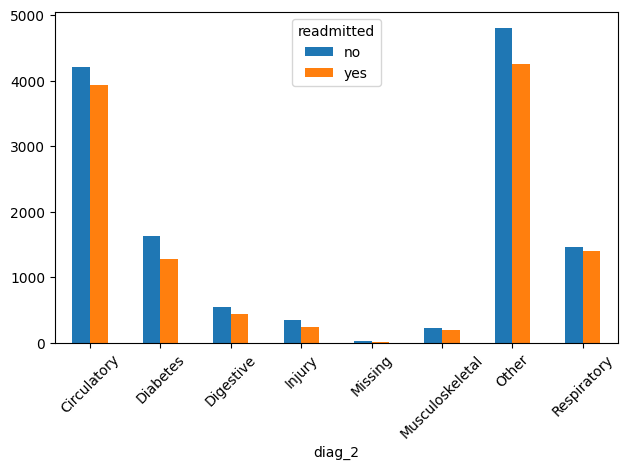

In [56]:
## Cat Vs Cat using stacked barchat 
top = df['diag_2'].value_counts().head(10).index
ct = pd.crosstab(df[df['diag_2'].isin(top)]['diag_2'],
                 df[df['diag_2'].isin(top)]['readmitted'])

ct.plot(kind='bar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

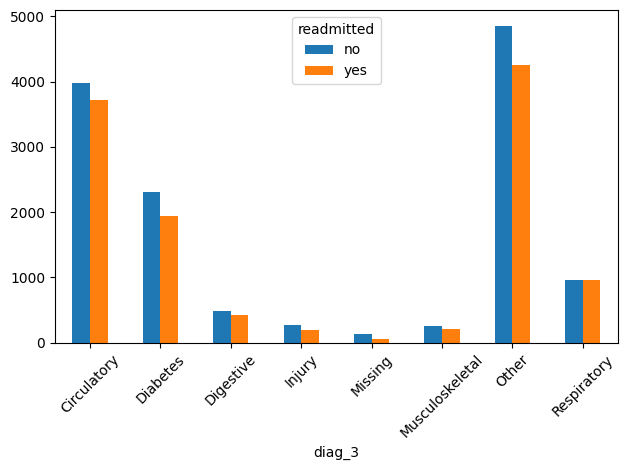

In [57]:
## Cat Vs Cat using stacked barchat 
top = df['diag_3'].value_counts().head(10).index
ct = pd.crosstab(df[df['diag_3'].isin(top)]['diag_3'],
                 df[df['diag_3'].isin(top)]['readmitted'])

ct.plot(kind='bar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
Cat_cols

Index(['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

<Axes: xlabel='readmitted', ylabel='glucose_test'>

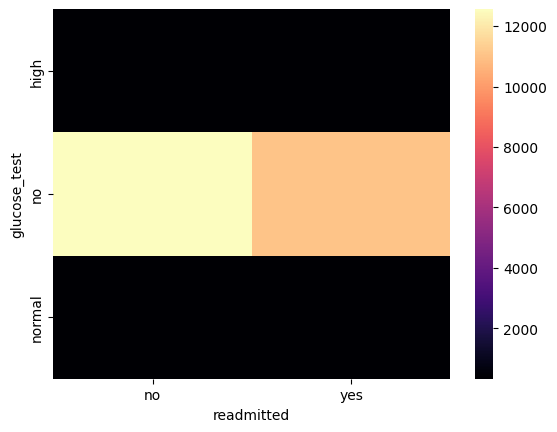

In [76]:
pd_cross = pd.crosstab(df2['glucose_test'], df2['readmitted'])
color=sb.color_palette("magma", as_cmap=True)
sb.heatmap(pd_cross, cmap=color)

<Axes: xlabel='readmitted', ylabel='A1Ctest'>

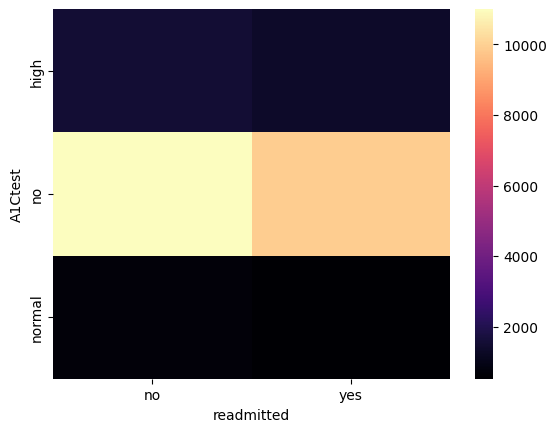

In [77]:
pd_cross = pd.crosstab(df2['A1Ctest'], df2['readmitted'])
color=sb.color_palette("magma", as_cmap=True)
sb.heatmap(pd_cross, cmap=color)

## 1. Univariate Analysis 

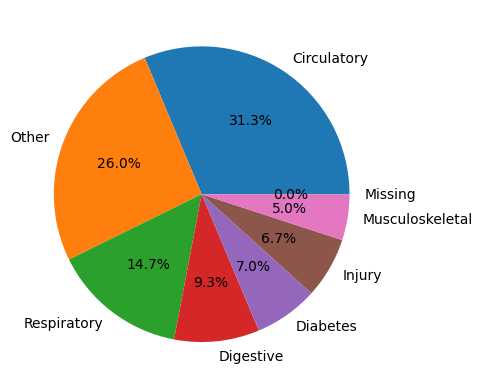

In [46]:
counts = df['diag_1'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',)
plt.show()

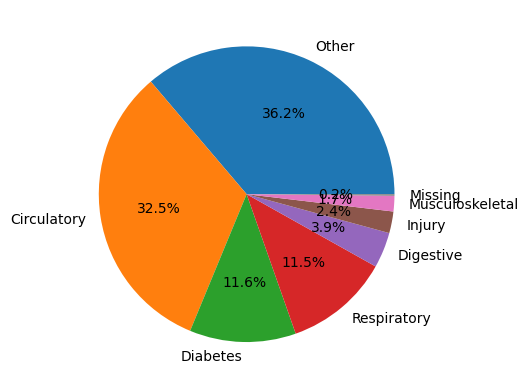

In [47]:
counts = df['diag_2'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',)
plt.show()

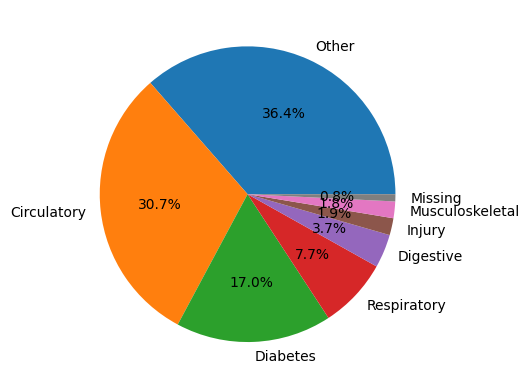

In [48]:
counts = df['diag_3'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',)
plt.show()

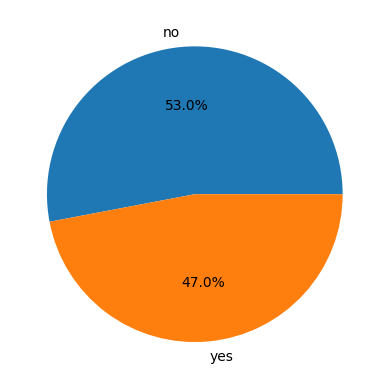

In [78]:
counts = df['readmitted'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',)
plt.show()

<Axes: xlabel='diag_1', ylabel='count'>

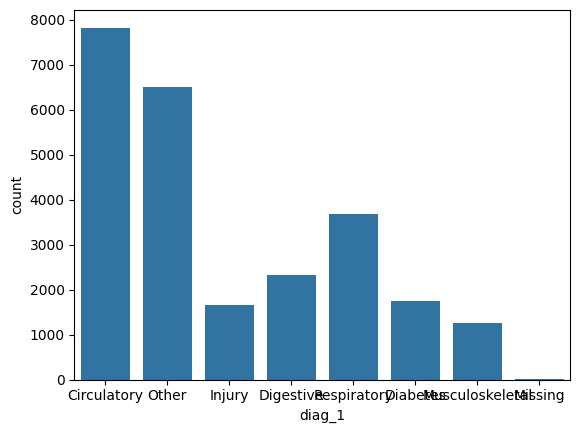

In [153]:
sb.countplot(df, x='diag_1')

<Axes: xlabel='diag_1', ylabel='Count'>

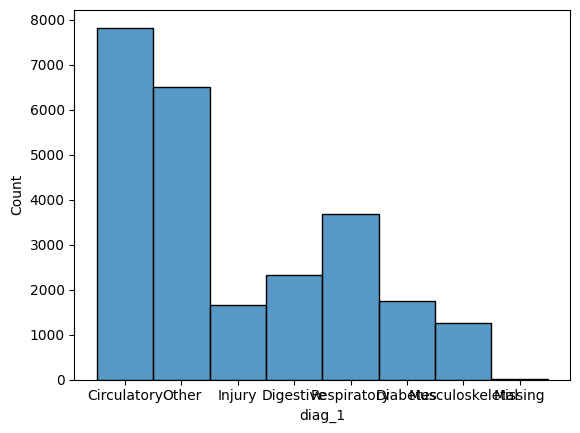

In [154]:
sb.histplot(df, x='diag_1')

## 2. Bi-Variate Analysis 

In [140]:
temp3 = df['age'].value_counts().reset_index()
temp3.columns = ['age', 'counts']


temp3['age_start'] = temp3['age'].str.extract(r'(\d+)').astype(int)
temp3 = temp3.sort_values('age_start').drop(columns='age_start')

temp3

,age,counts
4,[40-50),2532
3,[50-60),4452
1,[60-70),5913
0,[70-80),6837
2,[80-90),4516
5,[90-100),750


<Axes: xlabel='age', ylabel='counts'>

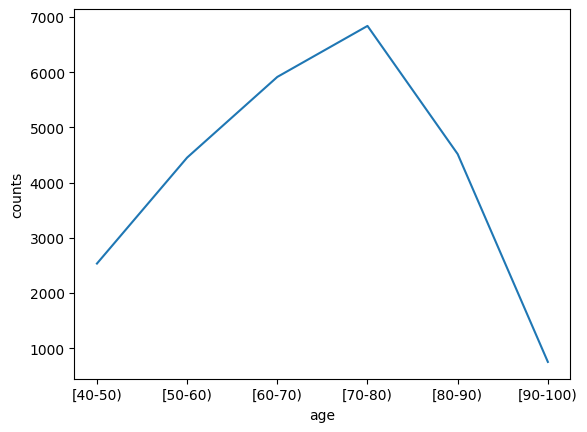

In [141]:

sb.lineplot(df,x=temp3.age,y=temp3.counts)

<Axes: xlabel='n_inpatient', ylabel='n_outpatient'>

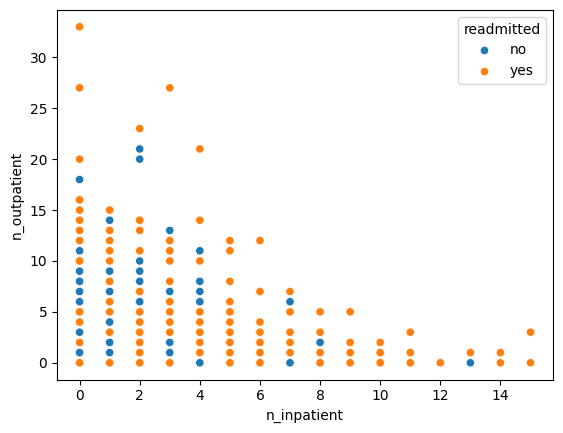

In [145]:
sb.scatterplot(df, x='n_inpatient',y='n_outpatient', hue='readmitted')

<Axes: xlabel='n_procedures', ylabel='n_lab_procedures'>

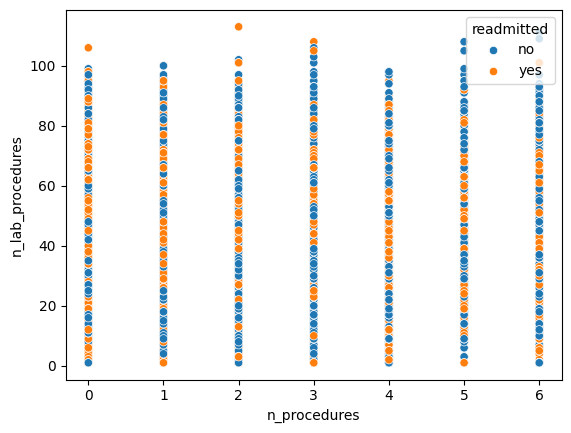

In [148]:
sb.scatterplot(df, x='n_procedures',y='n_lab_procedures', hue='readmitted')

# 3. Multi variate analysis

In [149]:
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Not specified,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Not specified,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Not specified,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,0,0,Not specified,Circulatory,Other,Circulatory,no,normal,no,no,yes
24996,[80-90),2,66,0,24,0,0,0,Not specified,Digestive,Injury,Other,no,high,yes,yes,yes
24997,[70-80),5,12,0,6,0,1,0,Not specified,Other,Other,Other,normal,no,no,no,yes
24998,[70-80),2,61,3,15,0,0,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,yes,no


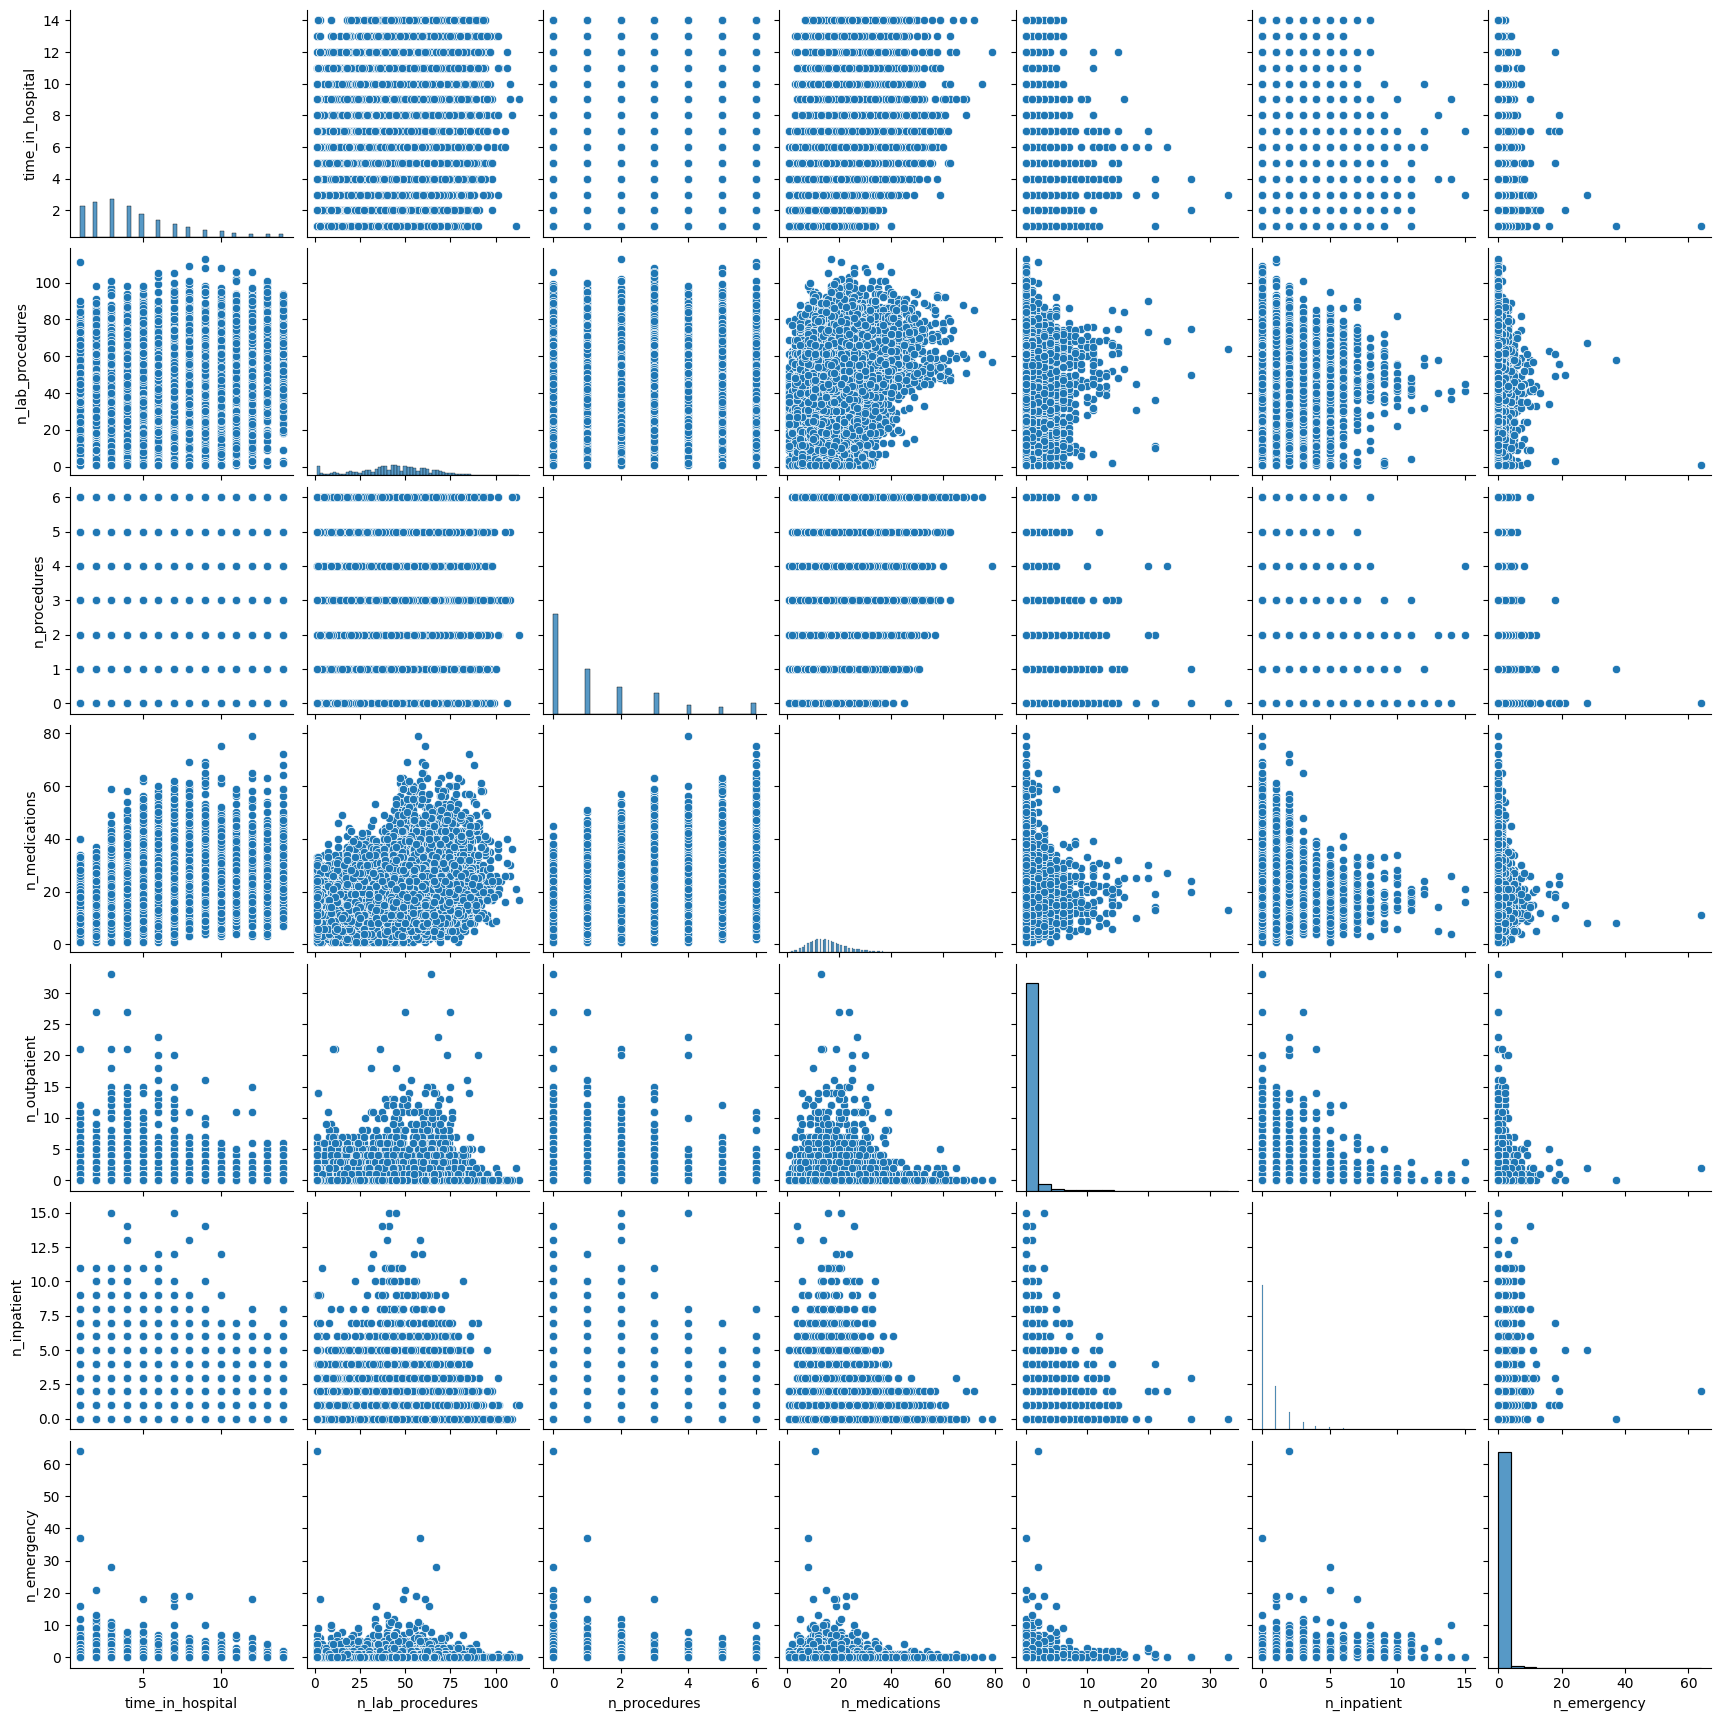

In [158]:
sb.pairplot(df)

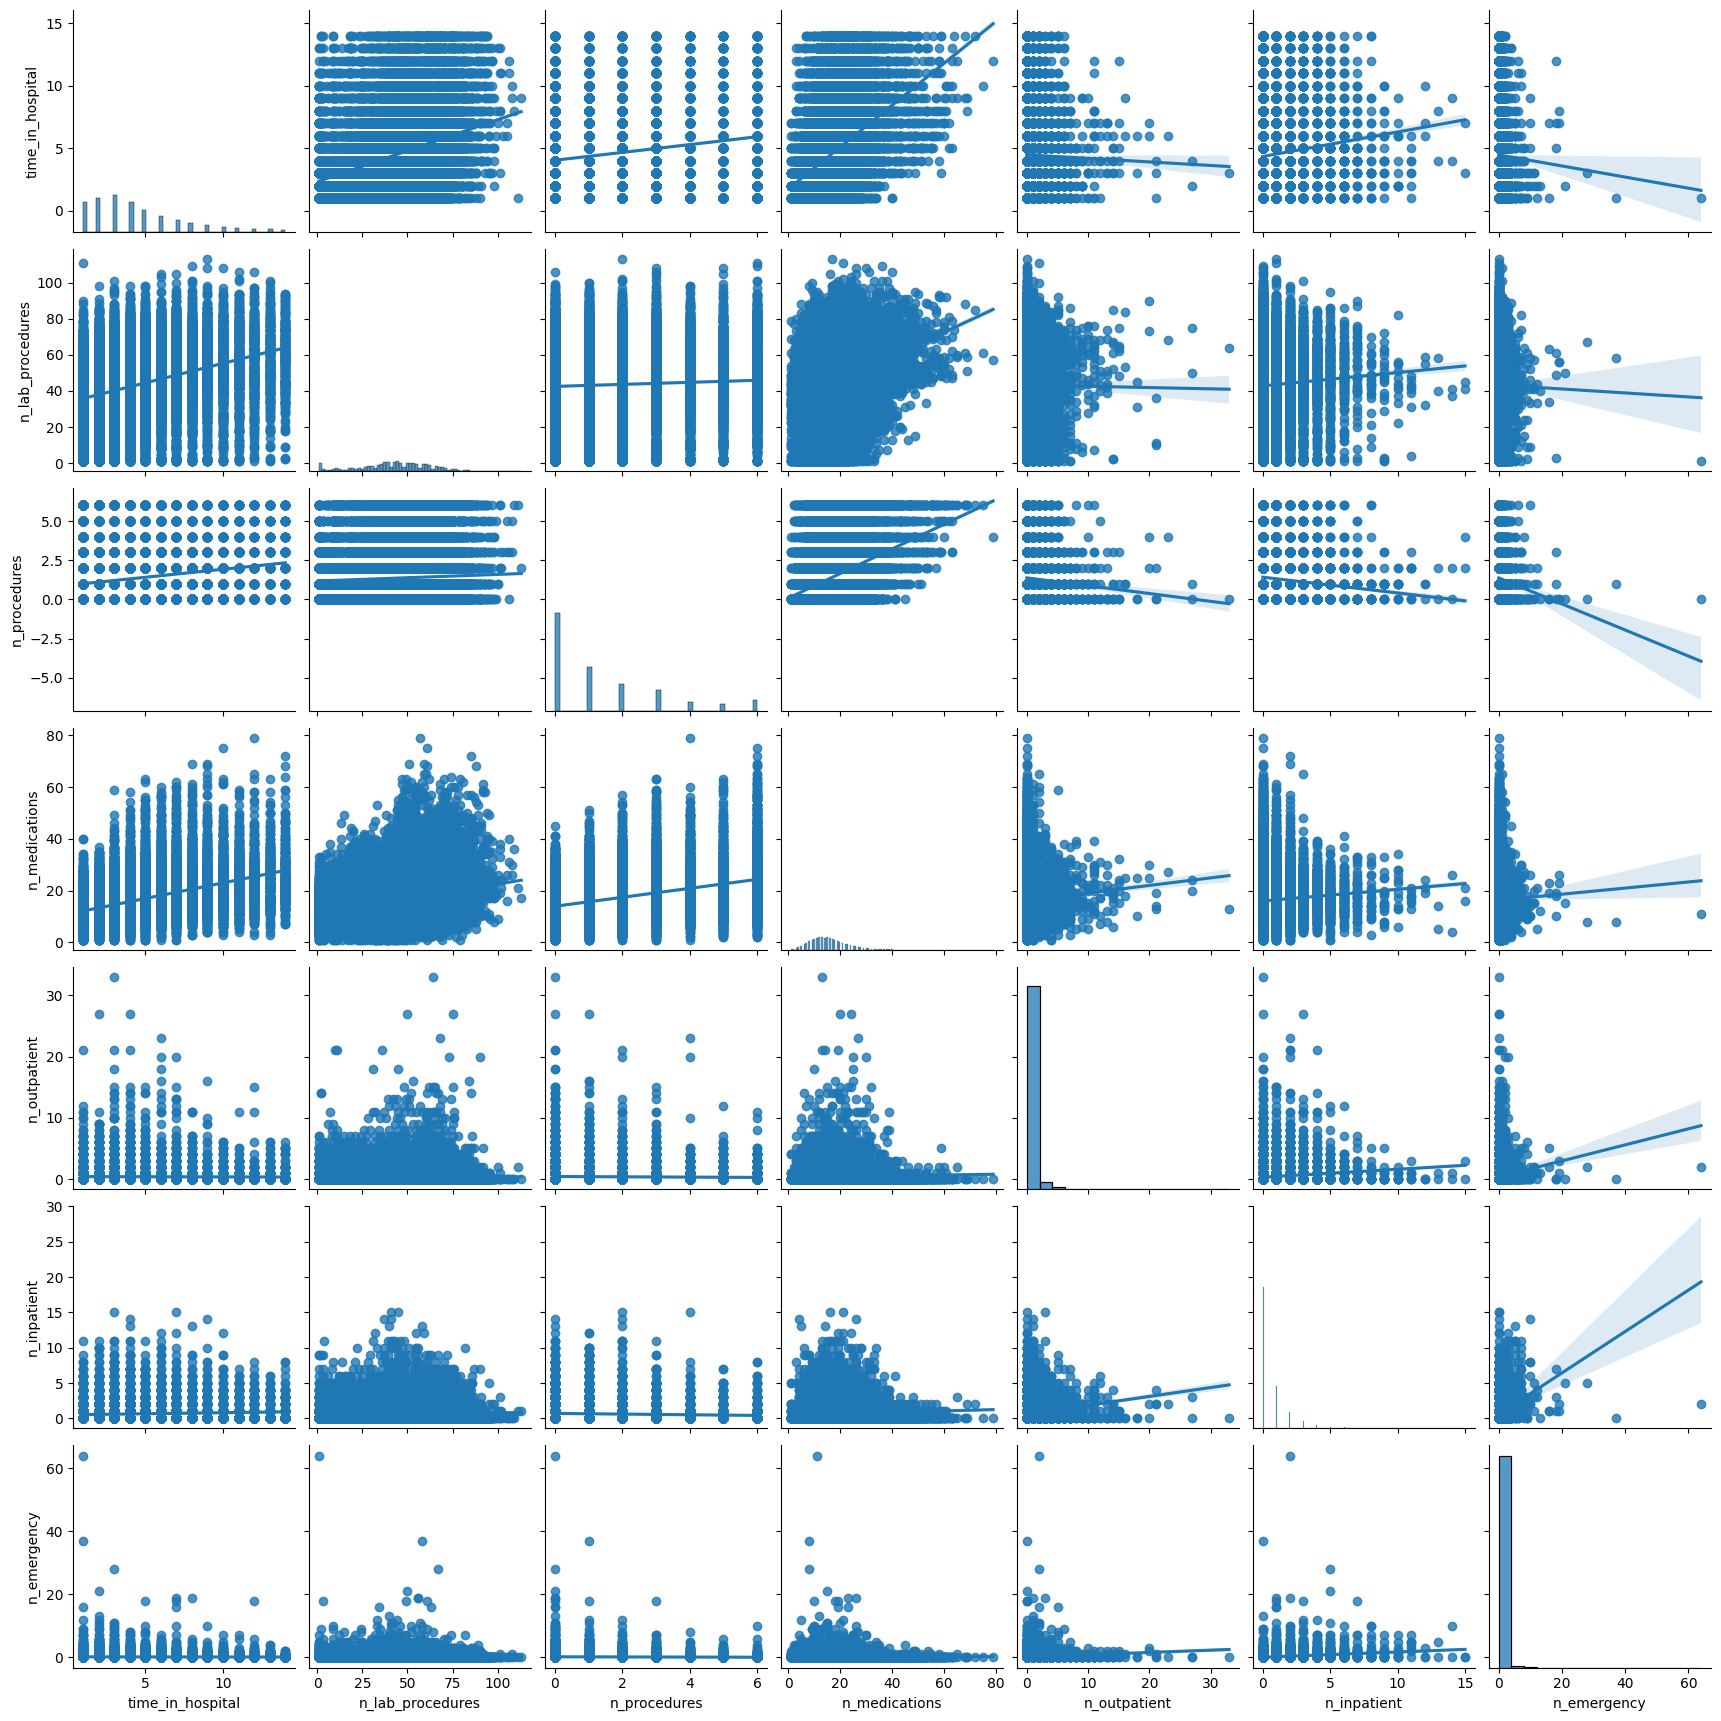

In [159]:
sb.pairplot(df,kind='reg' )

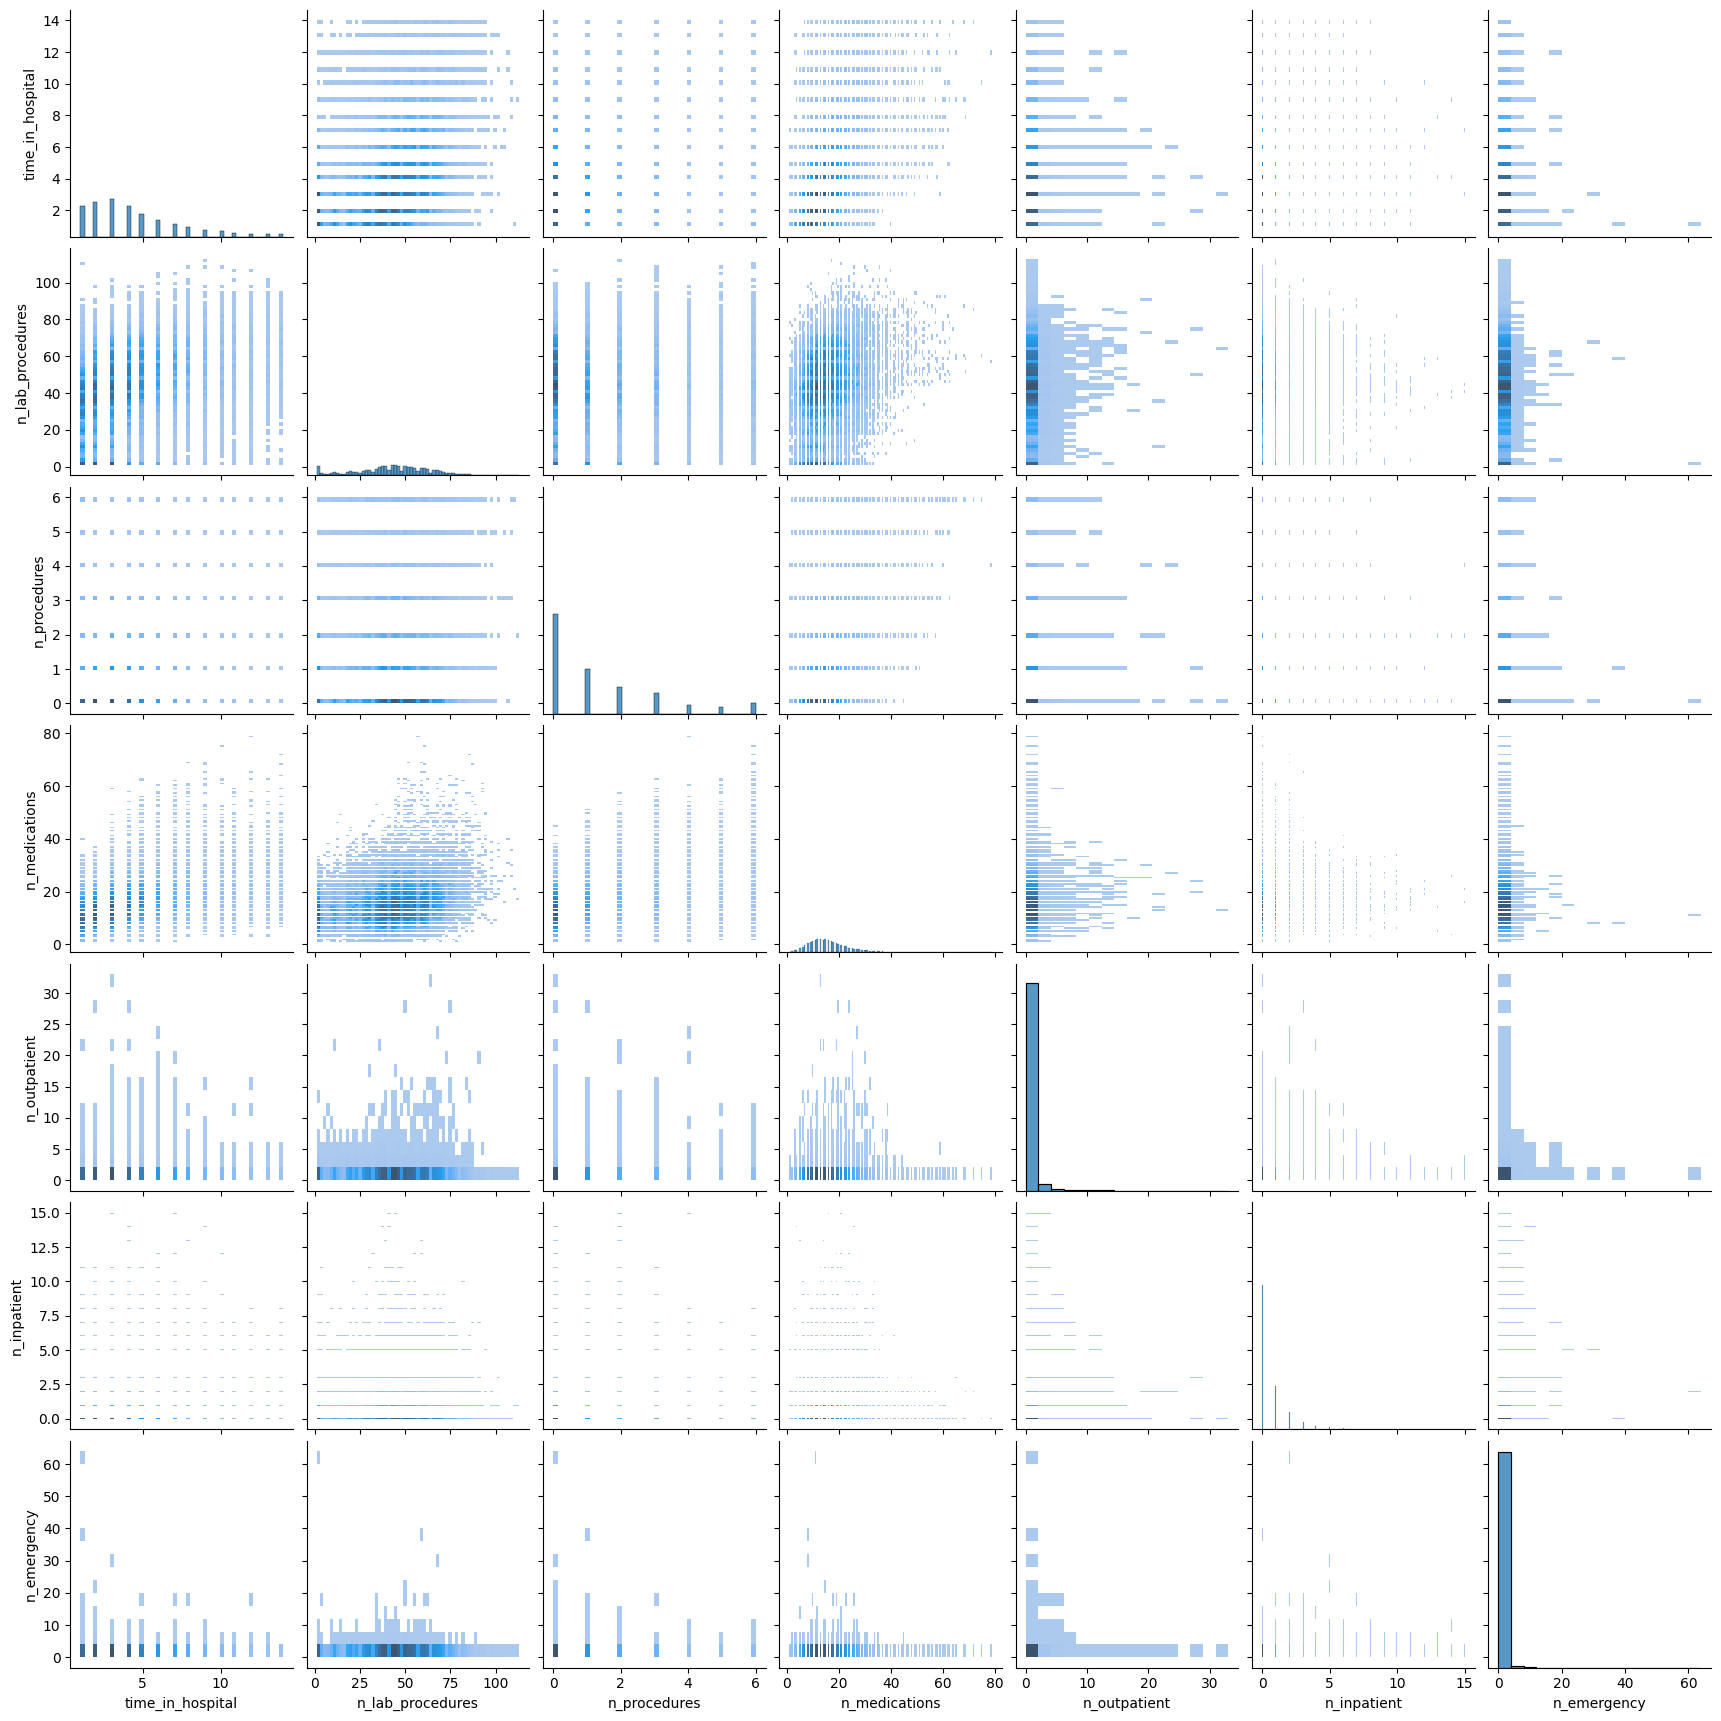

In [160]:
sb.pairplot(df,kind='hist' )

In [167]:
import os
os.getcwd()

'C:\\Users\\chidv\\Batch405\\ML\\project1'

In [170]:
df.to_csv(r'C:\\Users\\chidv\\Batch405\\ML\\project1\\Cleaned_data.csv',index=False)